In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import h5py, glob, re, os, gc, pickle, scipy.sparse, time
from shapely.geometry import Point, Polygon
import shapely
import glob, gc
import geopandas as gpd

basedir = '/data/srlab/AMP_collab/data/early_disease_synovium/'
xeniumdir = f'{basedir}/xenium'

In [2]:
metadata = pd.concat([
    pd.read_csv(f'{basedir}/Xenium_RA-SYN-EDP2_assay manifest.csv').assign(subset="RA"),
]).set_index('Sample_ID')

In [3]:
def read(slide_id):
    print('reading', slide_id)
    subset = metadata[metadata['Xenium-Slide_Sample_ID'] == slide_id].subset.iloc[0]
    path = glob.glob(f'{xeniumdir}/Xenium_{subset}-SYN-EDP2/Level_1_Xenium_Output/*{slide_id}*')[0]
    transcripts = pd.read_parquet(f'{path}/transcripts.parquet', engine='fastparquet')
    gene_transcripts = transcripts[transcripts.is_gene]
    return gene_transcripts[gene_transcripts.qv >= 20], subset, path

# Define sample polygons for each slide

In [4]:
def visualize(tx, polygons, figw=5, interval=2500):
    ix = np.random.choice(len(tx), 50000, replace=False)
    plt.figure(figsize=(figw,figw))
    plt.scatter(tx.iloc[ix].x_location, tx.iloc[ix].y_location, s=1, alpha=0.3)
    for name, polygon in polygons.items():
        plt.plot(*np.array(polygon.exterior.coords).T)
        plt.text(polygon.centroid.x, polygon.centroid.y, name, ha='center', va='center', fontsize=12, color='red')
    plt.axis('equal')
    ax = plt.gca()
    ax.grid(True, which='major')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(interval))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(interval))
    plt.show()

def annotate(slide_id, polygons, save=True, figw=5):
    for name in polygons.keys():
        if metadata.loc[name, 'Xenium-Slide_Sample_ID'] != slide_id:
            print('ERROR: sample id doesnt match slide')
            print('got:', name)
            print('samples on slide are:', metadata[metadata['Xenium-Slide_Sample_ID'] == slide_id].index)
            return
    
    tx, subset, path = read(slide_id)
    print(subset)
    visualize(tx, polygons, figw=figw)

    if save:
        data = {
            'sampleID': list(polygons.keys()),
            'slideID' : [slide_id] * len(polygons)
        }
        gdf = gpd.GeoDataFrame(
            data,
            geometry=list(polygons.values()),
            crs=None)
        gdf.attrs['name'] = f'xenium_bbox_synovium_{slide_id}'
        target = f'{xeniumdir}/Xenium_{subset}-SYN-EDP2/Level_2/'
        os.makedirs(target, exist_ok=True)
        gdf.to_file(f'{target}/xenium_bbox_synovium_{slide_id}.geojson', driver='GeoJSON')

    return tx

reading Slidearray0181
RA


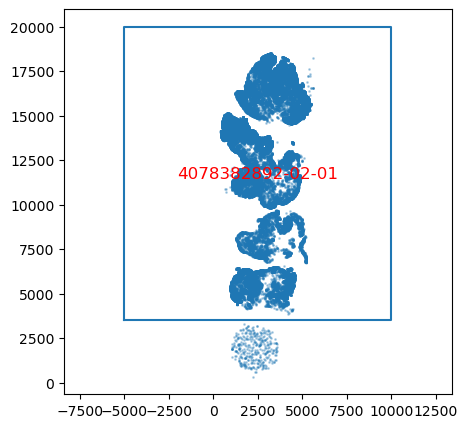

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [13]:
slide_id = 'Slidearray0181'
polys = {
    '4078382892-02-01':Polygon([(-5000, 3500), (-5000, 20000), (10000, 20000), (10000, 3500)])
}
tx = annotate(slide_id, polys)

reading Slidearray0179
RA


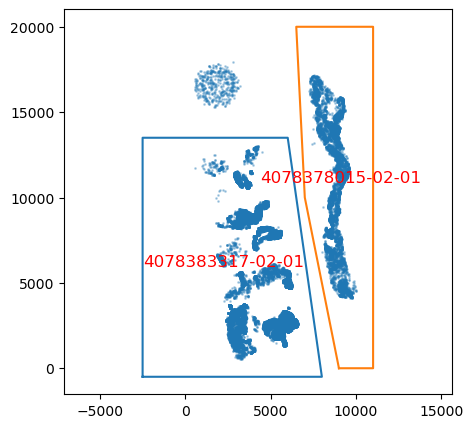

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [24]:
slide_id = 'Slidearray0179'
polys = {
    '4078383317-02-01':Polygon([(-2500, -500), (-2500, 13500), (6000, 13500), (8000, -500)]),
    '4078378015-02-01':Polygon([(9000, 0), (7000, 10000), (6500, 20000), (11000, 20000), (11000, 0)])
}
tx = annotate(slide_id, polys)

reading SlideArray0175
RA


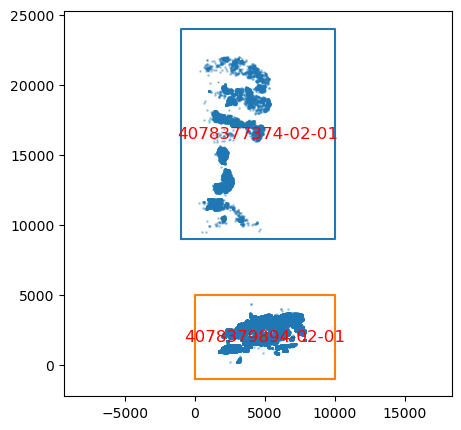

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [24]:
slide_id = 'SlideArray0175'
polys = {
    '4078377374-02-01':Polygon([(-1000, 9000), (-1000, 24000), (10000, 24000), (10000, 9000)]),
    '4078379894-02-01':Polygon([(0, -1000), (0, 5000), (10000, 5000), (10000, -1000)])
}
tx = annotate(slide_id, polys)

reading SlideArray0173
RA


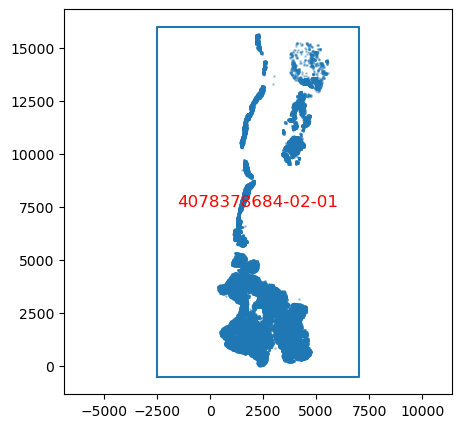

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [27]:
slide_id = 'SlideArray0173'
polys = {
    '4078378684-02-01':Polygon([(-2500, -500), (-2500, 16000), (7000, 16000), (7000, -500)]),
}
tx = annotate(slide_id, polys)

reading Slidearray0171
RA


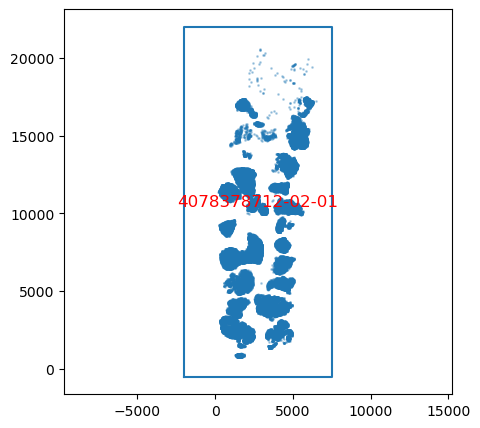

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [38]:
slide_id = 'Slidearray0171'
polys = {
    '4078378712-02-01':Polygon([(-2000, -500), (-2000, 22000), (7500, 22000), (7500, -500)]),
}
tx = annotate(slide_id, polys)

reading Slidearray0169
RA


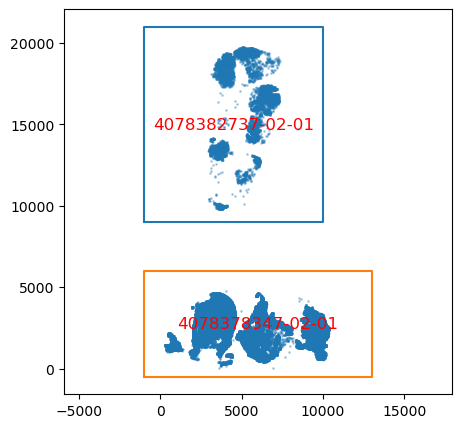

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [51]:
slide_id = 'Slidearray0169'
polys = {
    '4078382737-02-01':Polygon([(-1000, 9000), (-1000, 21000), (10000, 21000), (10000, 9000)]),
    '4078378347-02-01':Polygon([(-1000, -500), (-1000, 6000), (13000, 6000), (13000, -500)]),
}
tx = annotate(slide_id, polys)

reading 8073578700-01-01
RA


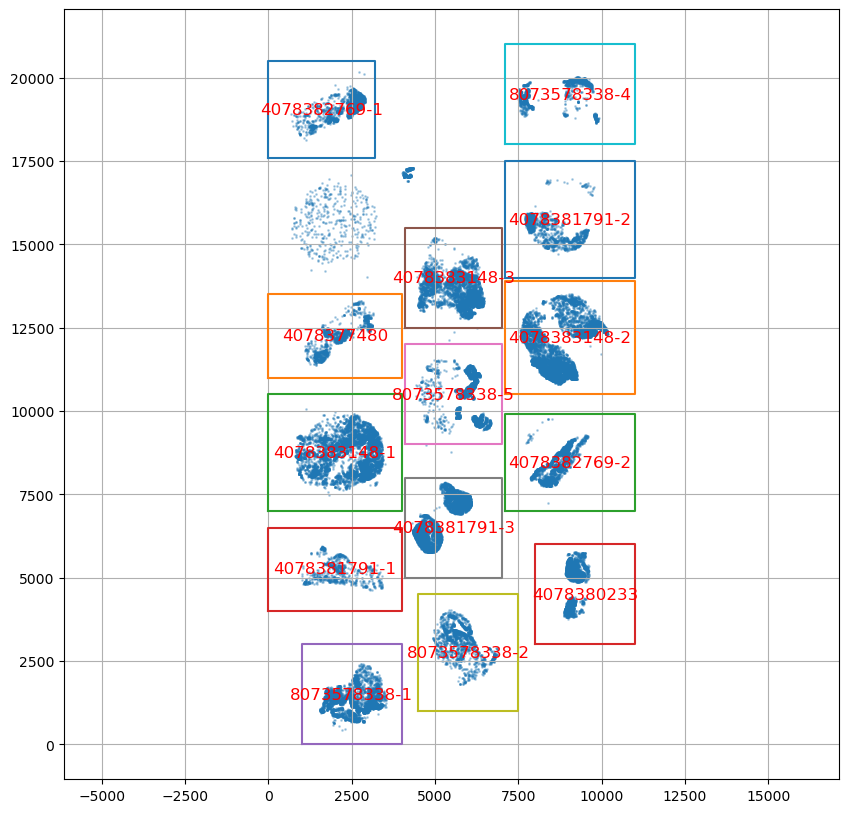

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [5]:
slide_id = '8073578700-01-01'
polys = {
    '4078382769-1':Polygon([(0, 17600), (0, 20500), (3200, 20500), (3200, 17600)]),
    '4078377480':Polygon([(0, 11000), (0, 13500), (4000, 13500), (4000, 11000)]),
    '4078383148-1':Polygon([(0, 7000), (0, 10500), (4000, 10500), (4000, 7000)]),
    '4078381791-1':Polygon([(0, 4000), (0, 6500), (4000, 6500), (4000, 4000)]),
    '8073578338-1':Polygon([(1000, 0), (1000, 3000), (4000, 3000), (4000, 0)]),
    '4078383148-3':Polygon([(4100, 12500), (4100, 15500), (7000, 15500), (7000, 12500)]),
    '8073578338-5':Polygon([(4100, 9000), (4100, 12000), (7000, 12000), (7000, 9000)]),
    '4078381791-3':Polygon([(4100, 5000), (4100, 8000), (7000, 8000), (7000, 5000)]),
    '8073578338-2':Polygon([(4500, 1000), (4500, 4500), (7500, 4500), (7500, 1000)]),
    '8073578338-4':Polygon([(7100, 18000), (7100, 21000), (11000, 21000), (11000, 18000)]),
    '4078381791-2':Polygon([(7100, 14000), (7100, 17500), (11000, 17500), (11000, 14000)]),
    '4078383148-2':Polygon([(7100, 10500), (7100, 13900), (11000, 13900), (11000, 10500)]),
    '4078382769-2':Polygon([(7100, 7000), (7100, 9900), (11000, 9900), (11000, 7000)]),
    '4078380233':Polygon([(8000, 3000), (8000, 6000), (11000, 6000), (11000, 3000)]),
}
tx = annotate(slide_id, polys, figw=10)

reading 8073578683-01-01
RA


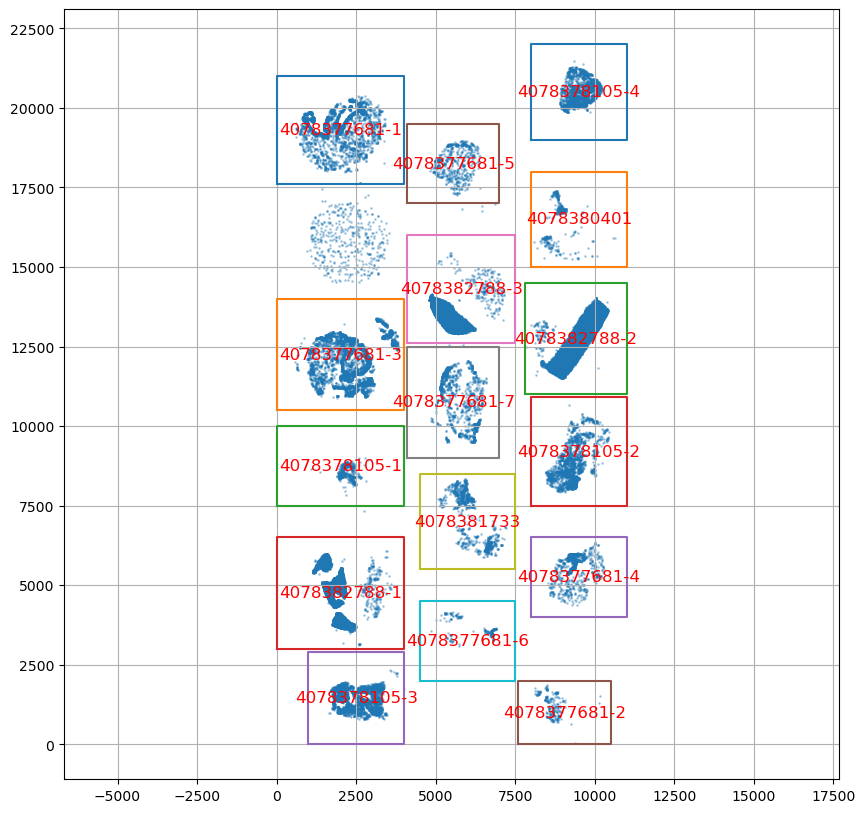

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [6]:
slide_id = '8073578683-01-01'
polys = {
    '4078377681-1':Polygon([(0, 17600), (0, 21000), (4000, 21000), (4000, 17600)]),
    '4078377681-3':Polygon([(0, 10500), (0, 14000), (4000, 14000), (4000, 10500)]),
    '4078378105-1':Polygon([(0, 7500), (0, 10000), (4000, 10000), (4000, 7500)]),
    '4078382788-1':Polygon([(0, 3000), (0, 6500), (4000, 6500), (4000, 3000)]),
    '4078378105-3':Polygon([(1000, 0), (1000, 2900), (4000, 2900), (4000, 0)]),
    '4078377681-5':Polygon([(4100, 17000), (4100, 19500), (7000, 19500), (7000, 17000)]),
    '4078382788-3':Polygon([(4100, 12600), (4100, 16000), (7500, 16000), (7500, 12600)]),
    '4078377681-7':Polygon([(4100, 9000), (4100, 12500), (7000, 12500), (7000, 9000)]),
    '4078381733':Polygon([(4500, 5500), (4500, 8500), (7500, 8500), (7500, 5500)]),
    '4078377681-6':Polygon([(4500, 2000), (4500, 4500), (7500, 4500), (7500, 2000)]),
    '4078378105-4':Polygon([(8000, 19000), (8000, 22000), (11000, 22000), (11000, 19000)]),
    '4078380401':Polygon([(8000, 15000), (8000, 18000), (11000, 18000), (11000, 15000)]),
    '4078382788-2':Polygon([(7800, 11000), (7800, 14500), (11000, 14500), (11000, 11000)]),
    '4078378105-2':Polygon([(8000, 7500), (8000, 10900), (11000, 10900), (11000, 7500)]),
    '4078377681-4':Polygon([(8000, 4000), (8000, 6500), (11000, 6500), (11000, 4000)]),
    '4078377681-2':Polygon([(7600, 0), (7600, 2000), (10500, 2000), (10500, 0)]),
}
tx = annotate(slide_id, polys, figw=10)

# Split into samples and QC transcripts and genes

## compute gene-level info, filter transcripts, and split samples

In [7]:
features = ['x_location', 'y_location', 'z_location', 'qv', 'nucleus_distance']

t0 = time.time()
os.makedirs('out/_gene_qc_metrics_edp2only', exist_ok=True)
nslides = len(metadata['Xenium-Slide_Sample_ID'].unique())
for i, slide_id in enumerate(metadata['Xenium-Slide_Sample_ID'].unique()):
    print(f'slide {i+1} of {nslides}, time: {time.time() - t0:.2f}')
    tx, subset, path = read(slide_id)
    print(subset)
    print(f'\t{len(tx)} transcripts')
    
    gene_info = tx[['feature_name']+features].groupby(by='feature_name').aggregate('mean')
    gene_info['ntranscripts'] = tx.feature_name.value_counts()
    gene_info['codeword_category'] = tx[['feature_name','codeword_category']].drop_duplicates().set_index('feature_name', drop=True).codeword_category
    gene_info['slide_id'] = slide_id
    gene_info.to_csv(f'out/_gene_qc_metrics_edp2only/{slide_id}.csv')

    targetdir = f'out/samples'
    os.makedirs(targetdir, exist_ok=True)
    boundaries = gpd.read_file(f'{xeniumdir}/Xenium_{subset}-SYN-EDP2/Level_2/xenium_bbox_synovium_{slide_id}.geojson')
    for sid, poly in zip(boundaries.sampleID, boundaries.geometry):
        inside = shapely.contains_xy(poly, tx.x_location.values, tx.y_location.values)
        sample = tx[inside]
        print(f'\twriting {sid} ({len(sample)} transcripts)')
        outdir = f'{targetdir}/{sid}'
        if os.path.exists(outdir):
            print(f'\t!!! WAIT: {outdir} already exists! Did NOT overwrite.')
            raise ValueError()
        os.makedirs(outdir, exist_ok=True)
        sample.to_parquet(f'{outdir}/transcripts_txqc.parquet')
        del sample; gc.collect()
    del tx; gc.collect()

slide 1 of 8, time: 0.02
reading Slidearray0181
RA
	51215670 transcripts
	writing 4078382892-02-01 (50848560 transcripts)
slide 2 of 8, time: 77.26
reading Slidearray0179
RA
	33735941 transcripts
	writing 4078383317-02-01 (28243155 transcripts)
	writing 4078378015-02-01 (5182424 transcripts)
slide 3 of 8, time: 124.17
reading SlideArray0175
RA
	32009569 transcripts
	writing 4078377374-02-01 (7558577 transcripts)
	writing 4078379894-02-01 (24450992 transcripts)
slide 4 of 8, time: 169.75
reading SlideArray0173
RA
	48445365 transcripts
	writing 4078378684-02-01 (48445365 transcripts)
slide 5 of 8, time: 231.29
reading Slidearray0171
RA
	131695950 transcripts
	writing 4078378712-02-01 (131695950 transcripts)
slide 6 of 8, time: 397.46
reading Slidearray0169
RA
	109205870 transcripts
	writing 4078382737-02-01 (16522369 transcripts)
	writing 4078378347-02-01 (92683501 transcripts)
slide 7 of 8, time: 545.44
reading 8073578700-01-01
RA
	47123399 transcripts
	writing 4078382769-1 (2012893 tra

In [8]:
gene_infos = pd.concat([pd.read_csv(f) for f in glob.glob(f'out/_gene_qc_metrics_edp2only/*.csv')], ignore_index=True)
gene_infos.to_parquet('out/_gene_qc_metrics_edp2only/all.parquet')

## QC genes

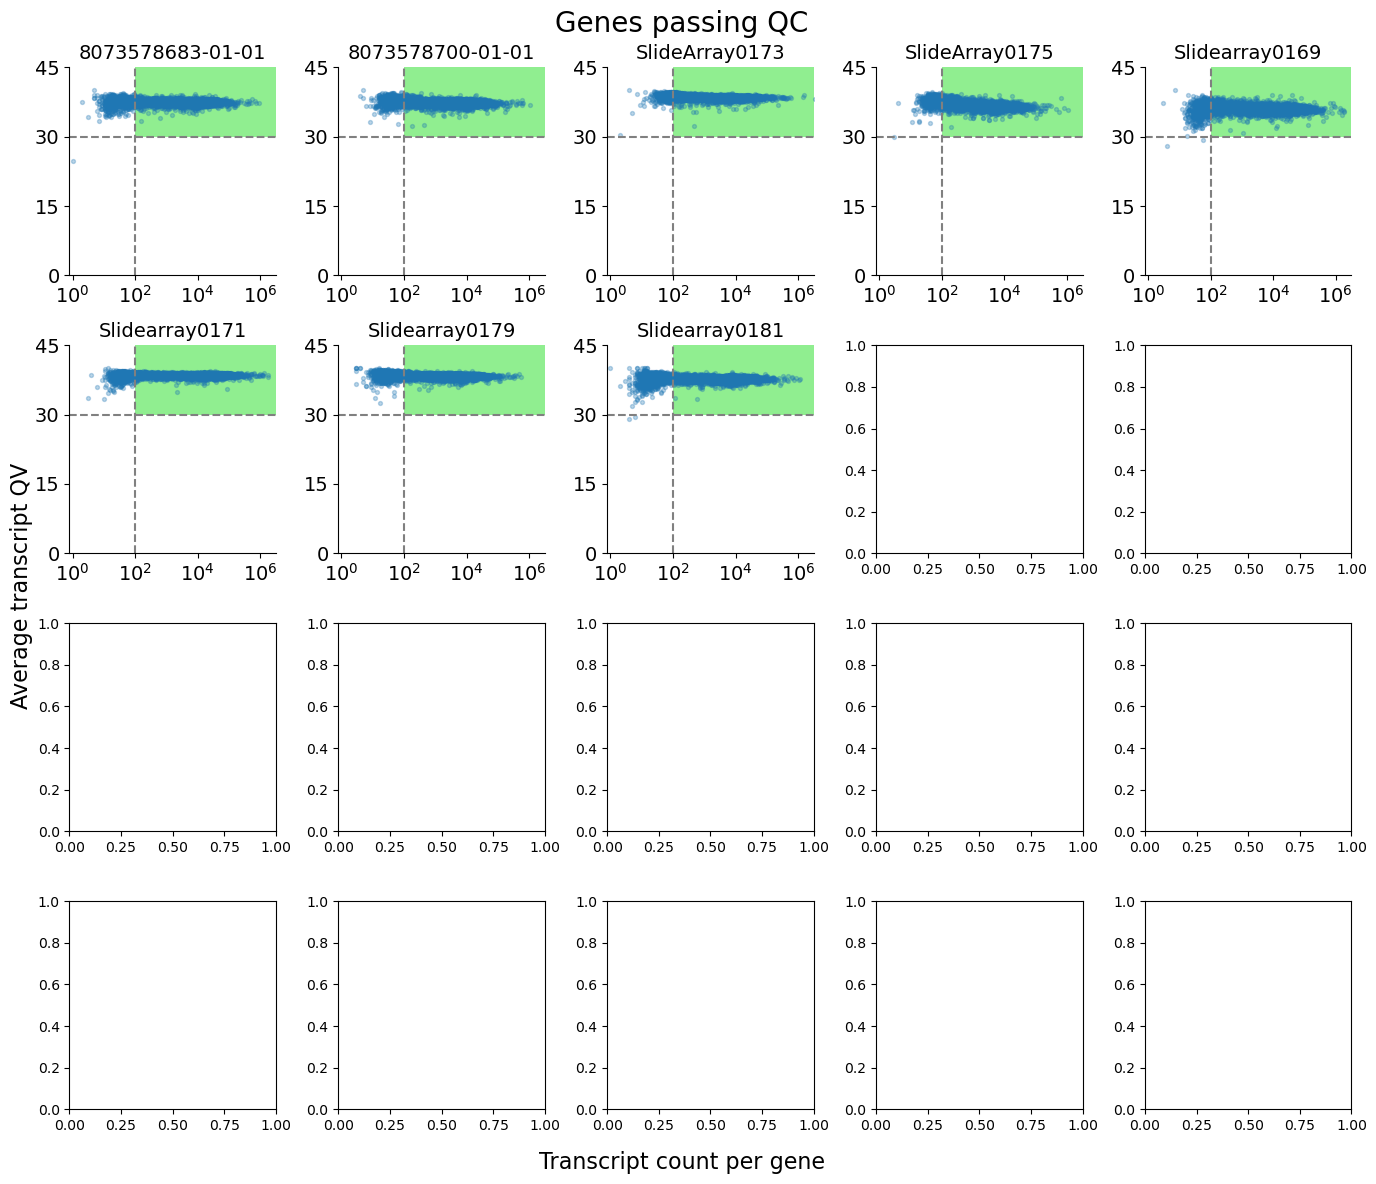

In [9]:
gene_infos = pd.read_parquet('out/_gene_qc_metrics_edp2only/all.parquet')
f, axs = plt.subplots(4,5,figsize=(14,12))
for ax, slide_id in zip(axs.flatten(), sorted(gene_infos.slide_id.unique())):
    gi = gene_infos[gene_infos.slide_id == slide_id]
    
    ax.axvspan(xmin=2, xmax=7, ymin=30/45, ymax=1, facecolor='lightgreen')
    ax.scatter(np.log10(gi.ntranscripts), gi.qv, s=8, alpha=0.3)
    ax.axhline(y=30, color='gray', ls='--')
    ax.axvline(x=np.log10(100), color='gray', ls='--')
    ax.set_xlim(-0.1, 6.5)
    ax.set_xticks([0, 2, 4, 6], labels=['$10^0$','$10^2$','$10^4$','$10^6$'], fontsize=14)
    ax.set_yticks([0, 15,30,45], labels=['0', '15', '30', '45'], fontsize=14)
    ax.spines[['right','top']].set_visible(False)
    ax.set_title(slide_id, fontsize=14)
f.supxlabel('Transcript count per gene', fontsize=16)
f.supylabel('Average transcript QV', fontsize=16) 
f.suptitle('Genes passing QC', fontsize=20) 
plt.tight_layout()
plt.show()

In [12]:
from collections import defaultdict
good_gene_counts = defaultdict(int)

good_genes = set()
for slide_id in sorted(gene_infos.slide_id.unique()):
    gi = gene_infos[gene_infos.slide_id == slide_id].set_index('feature_name', drop=True)
    my_good_genes = gi.index[(gi.qv >= 30) & (gi.ntranscripts >= 100)].values
    for g in my_good_genes:
        good_gene_counts[g] = good_gene_counts[g] + 1

gi = gene_infos[gene_infos.slide_id == 'Slidearray0181'].set_index('feature_name', drop=True)
good_gene_counts = pd.Series(good_gene_counts)
global_gene_info = pd.DataFrame({'nslides':good_gene_counts, 'codeword_category':gi.codeword_category})
good_genes = global_gene_info[global_gene_info.nslides >= 0.75*len(gene_infos.slide_id.unique())].index.values
print(global_gene_info.loc[good_genes].codeword_category.value_counts())

codeword_category
predesigned_gene    4157
custom_gene           84
Name: count, dtype: int64


In [14]:
# check which custom genes didn't make the cut
gi = gene_infos[gene_infos.slide_id == 'Slidearray0181'].set_index('feature_name', drop=True)
set(gi[gi.codeword_category == 'custom_gene'].index) - set(good_genes)

{'ASCL3',
 'CFHR4',
 'FLG',
 'FLG2',
 'HRNR',
 'IFNK',
 'IL36A',
 'IL36RN',
 'KRT14',
 'KRT15',
 'KRT2',
 'KRT6B',
 'KRT6C',
 'LCN2',
 'NPHS1',
 'NPHS2'}

In [15]:
# TODO: remove this later
# determine the good genes for edp1 and filter to them
gene_infos = pd.read_parquet('out/_gene_qc_metrics/all.parquet')
from collections import defaultdict
good_gene_counts = defaultdict(int)

good_genes = set()
for slide_id in sorted(gene_infos.slide_id.unique()):
    gi = gene_infos[gene_infos.slide_id == slide_id].set_index('feature_name', drop=True)
    my_good_genes = gi.index[(gi.qv >= 30) & (gi.ntranscripts >= 100)].values
    for g in my_good_genes:
        good_gene_counts[g] = good_gene_counts[g] + 1

gi = gene_infos[gene_infos.slide_id == 'slidearray0081'].set_index('feature_name', drop=True)
good_gene_counts = pd.Series(good_gene_counts)
global_gene_info = pd.DataFrame({'nslides':good_gene_counts, 'codeword_category':gi.codeword_category})
good_genes = global_gene_info[global_gene_info.nslides >= 0.75*len(gene_infos.slide_id.unique())].index.values
print(global_gene_info.loc[good_genes].codeword_category.value_counts())

codeword_category
predesigned_gene    3928
custom_gene           80
Name: count, dtype: int64


In [18]:
# filter each sample to just the transcripts from the good genes
for sid in metadata.index:
    sample_dir = f'out/samples/{sid}'
    transcripts = pd.read_parquet(f'{sample_dir}/transcripts_txqc.parquet')
    filtered_transcripts = transcripts[transcripts.feature_name.isin(good_genes)]
    filtered_transcripts.to_parquet(f'{sample_dir}/transcripts_txqc_geneqc.parquet')
    print(f'{sample_dir} : {len(transcripts)} -> {len(filtered_transcripts)}')
    del transcripts; del filtered_transcripts; gc.collect()

out/samples/4078382892-02-01 : 50848560 -> 50785575
out/samples/4078383317-02-01 : 28243155 -> 28141141
out/samples/4078378015-02-01 : 5182424 -> 5167878
out/samples/4078377374-02-01 : 7558577 -> 7483371
out/samples/4078379894-02-01 : 24450992 -> 24414493
out/samples/4078378684-02-01 : 48445365 -> 48265454
out/samples/4078378712-02-01 : 131695950 -> 131266028
out/samples/4078382737-02-01 : 16522369 -> 16440969
out/samples/4078378347-02-01 : 92683501 -> 92580569
out/samples/4078382769-1 : 2012893 -> 2009075
out/samples/4078377480 : 1420771 -> 1414570
out/samples/4078383148-1 : 6796767 -> 6783800
out/samples/4078381791-1 : 768190 -> 763331
out/samples/8073578338-1 : 3864149 -> 3857085
out/samples/4078383148-3 : 5104272 -> 5096723
out/samples/8073578338-5 : 2459156 -> 2454431
out/samples/4078381791-2 : 1687522 -> 1675266
out/samples/8073578338-2 : 1732777 -> 1727172
out/samples/8073578338-4 : 1464799 -> 1461886
out/samples/4078381791-3 : 4863676 -> 4832035
out/samples/4078383148-2 : 85417

# Sanity checks

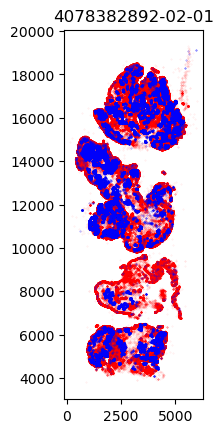

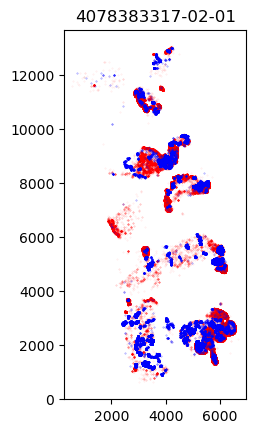

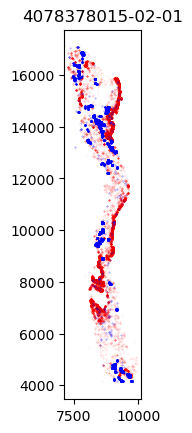

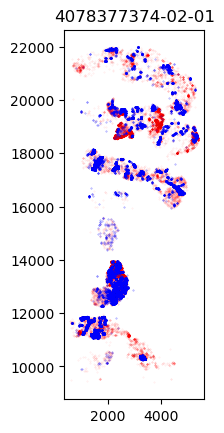

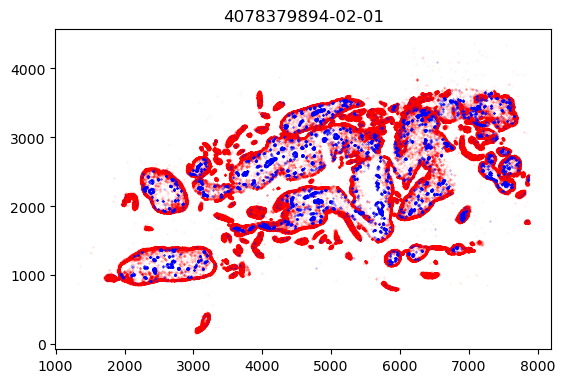

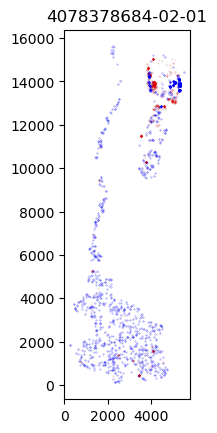

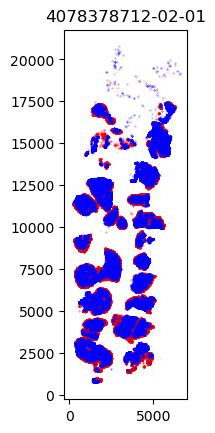

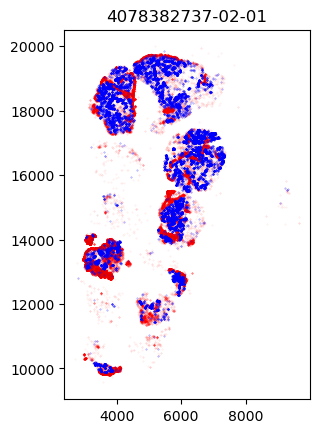

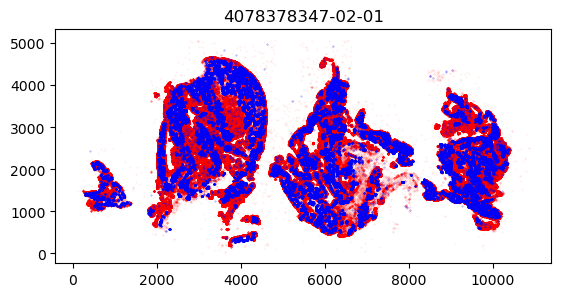

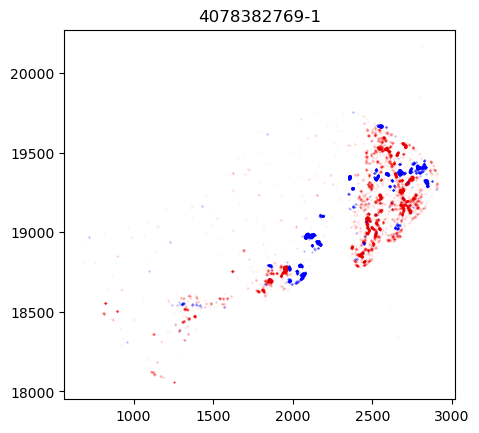

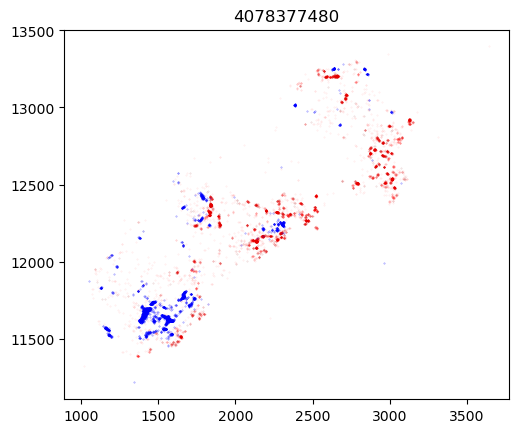

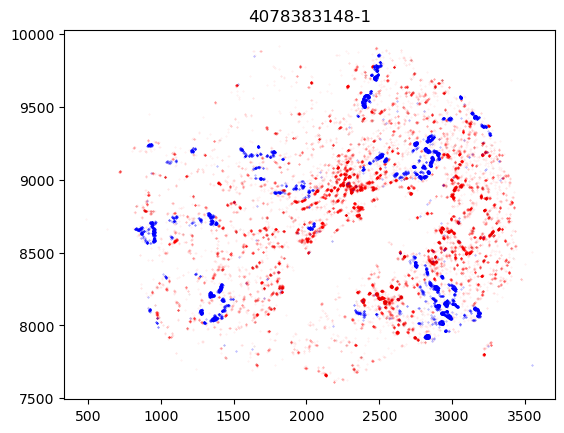

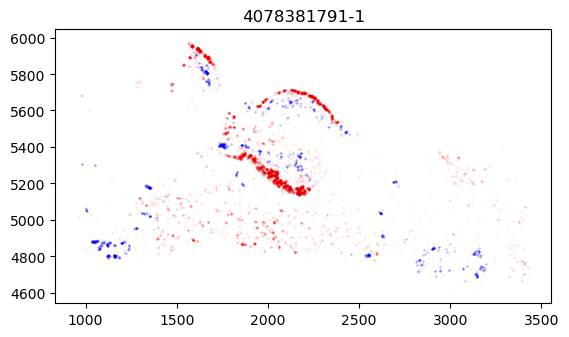

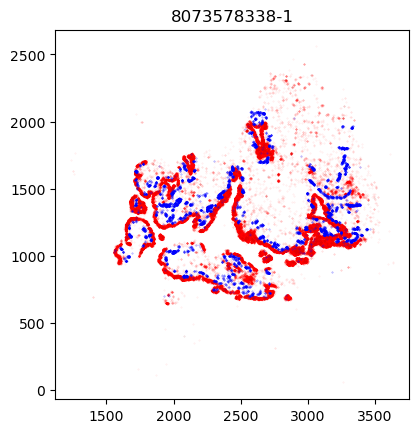

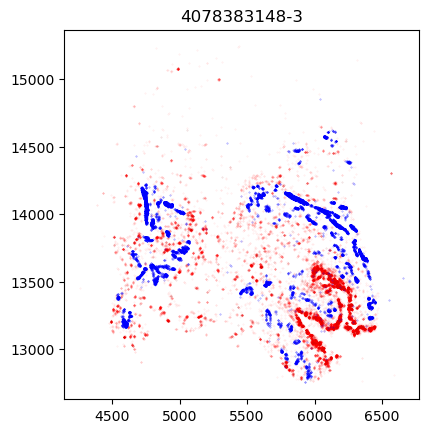

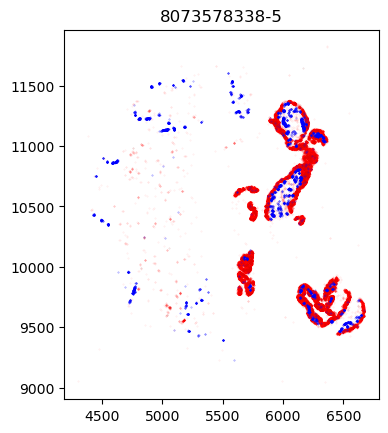

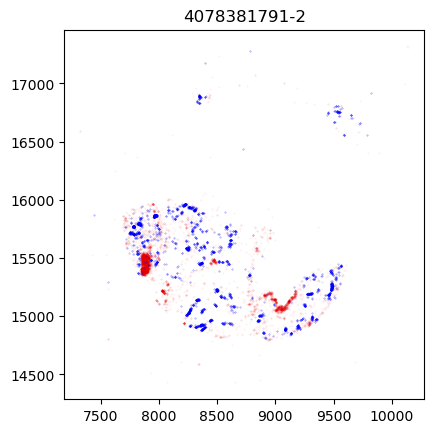

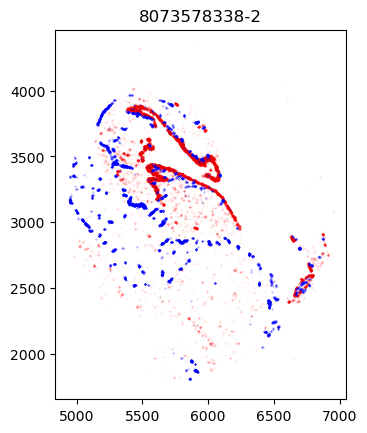

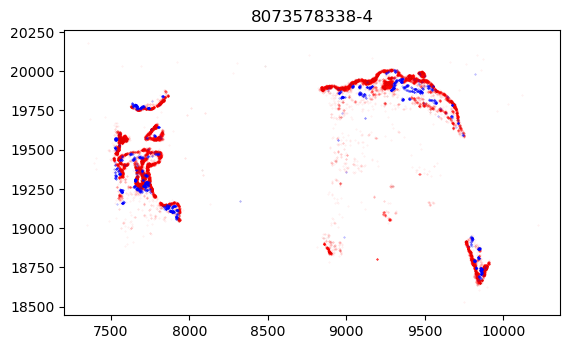

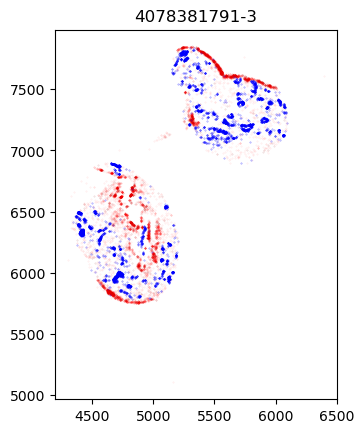

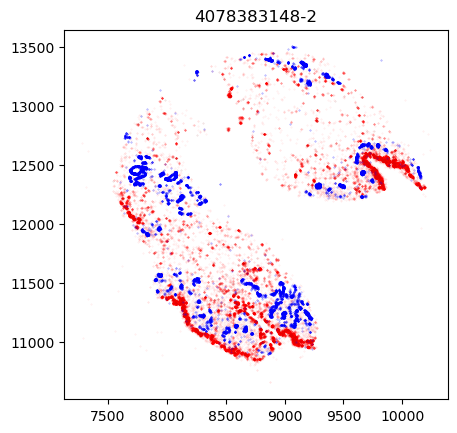

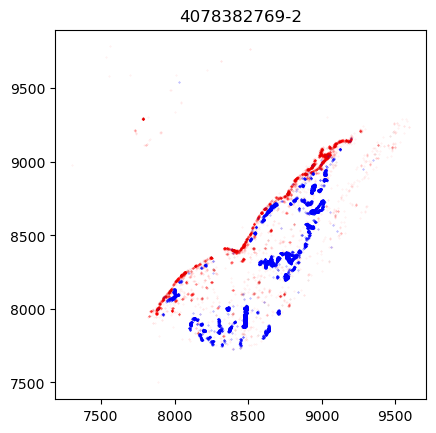

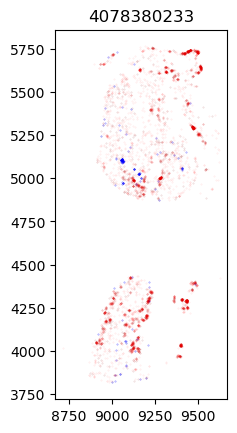

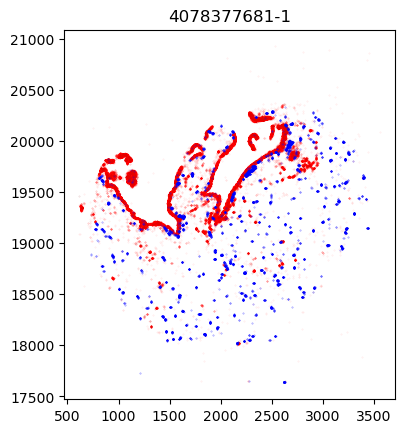

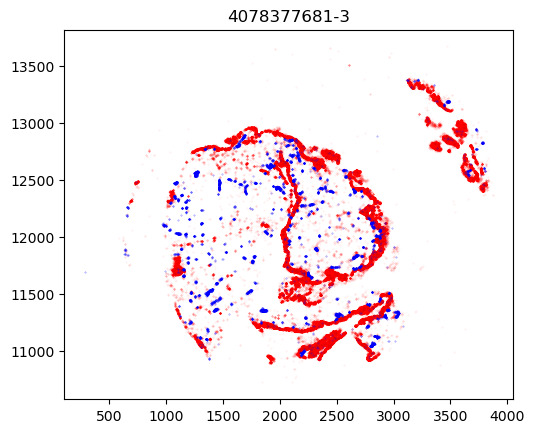

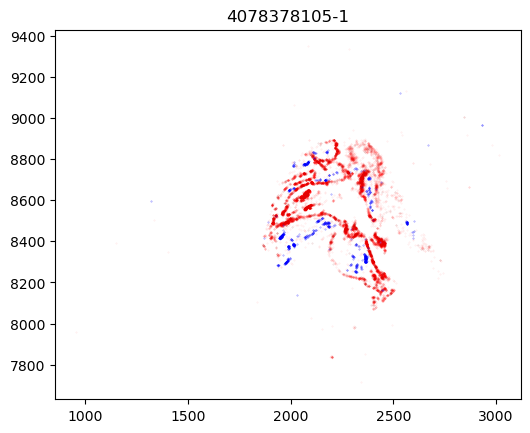

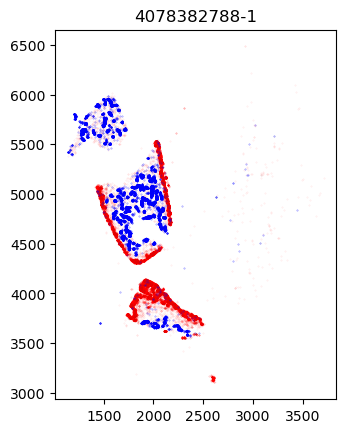

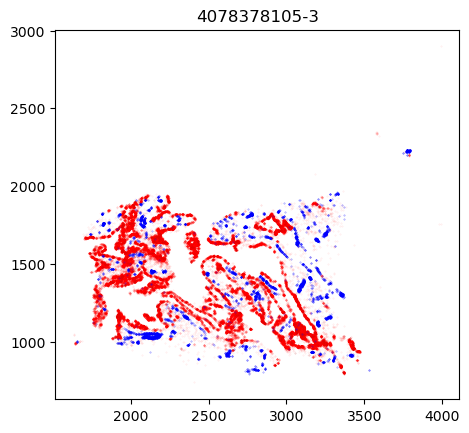

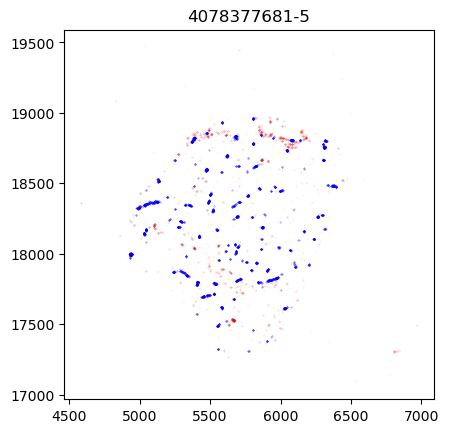

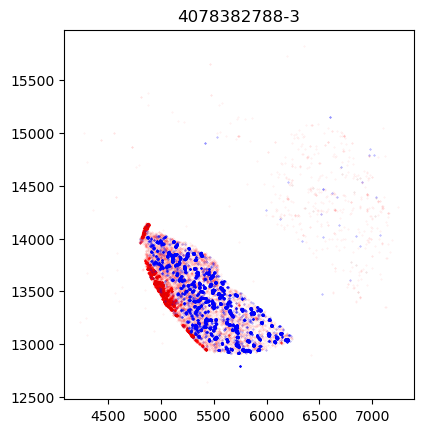

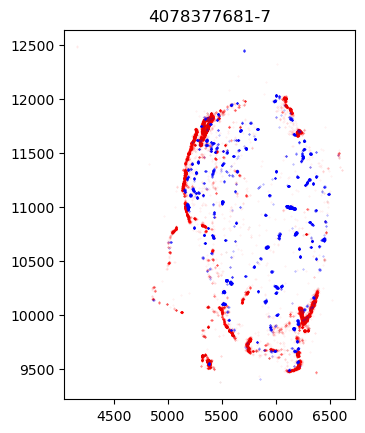

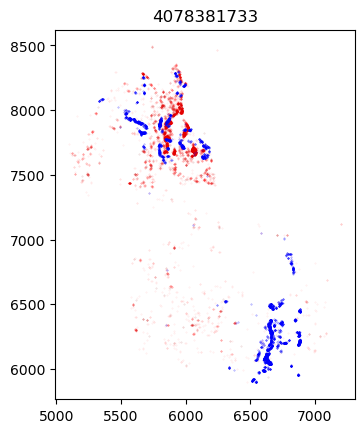

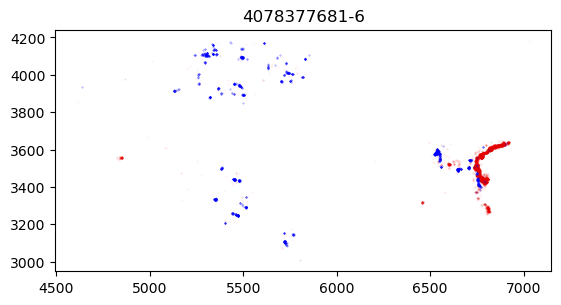

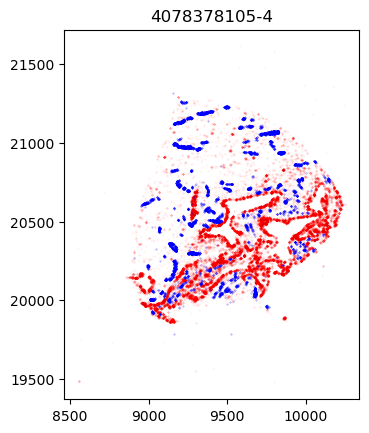

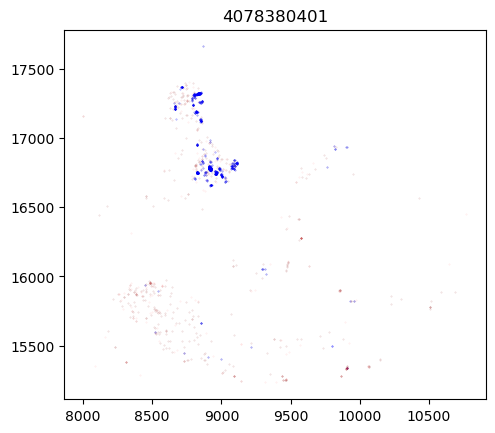

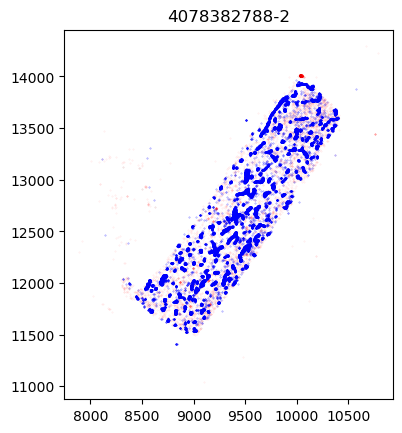

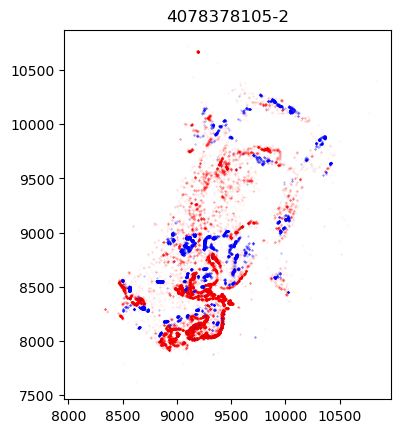

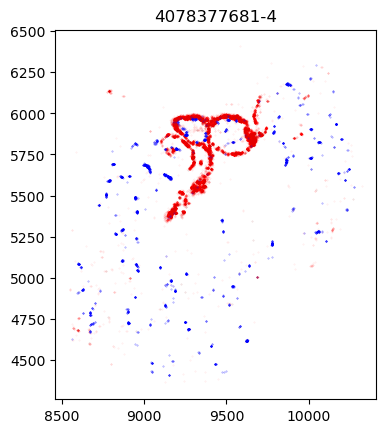

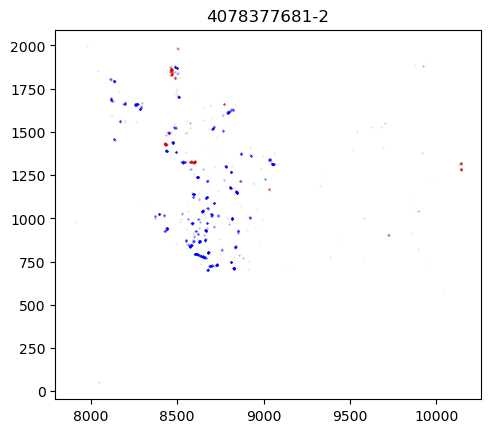

In [22]:
for sid in metadata.index:
    sample_dir = f'out/samples/{sid}'
    transcripts = pd.read_parquet(f'{sample_dir}/transcripts_txqc_geneqc.parquet')
    sid = sample_dir.split('/')[-1]
    
    transcripts = transcripts[transcripts.feature_name.isin(['VWF','PRG4'])]
    if len(transcripts) > 1000:
        ix = np.random.choice(len(transcripts), 1000, replace=False)
    else:
        ix = np.arange(len(transcripts))
    subset = transcripts.iloc[ix]
                              
    plt.scatter(subset.x_location, subset.y_location, s=0.1, alpha=0.2, color='gray')
    vwf = transcripts[transcripts.feature_name == 'VWF']
    prg4 = transcripts[transcripts.feature_name == 'PRG4']
    plt.scatter(prg4.x_location, prg4.y_location, color='red', s=0.1, alpha=0.1)
    plt.scatter(vwf.x_location, vwf.y_location, color='blue', s=0.1, alpha=0.5)
    plt.gca().set_aspect("equal")
    plt.title(sid)
    plt.show()
    del transcripts; del subset; gc.collect()